# Day 1: Mutual Fund Data Exploration (Bluestock MF Capstone)

This notebook loads the Mutual Fund Master dataset (`01_fund_master.csv`) and performs exploratory data analysis (EDA), displaying unique dimensions and visualizing the distribution of funds across fund houses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

In [2]:
# Define pathlib path to load fund_master.csv
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else Path("bluestock_mf_capstone")
fm_path = project_root / "data" / "raw" / "01_fund_master.csv"

if not fm_path.exists():
    fm_path = project_root / "data" / "raw" / "fund_master.csv"

print(f"Loading fund master from: {fm_path}")
df_fm = pd.read_csv(fm_path)
df_fm.head(3)

Loading fund master from: C:\Users\Asus\OneDrive\Code_X\DAY 1 — Project Setup + Data Ingestion (ETL)\bluestock_mf_capstone\data\raw\01_fund_master.csv


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03


In [3]:
# Exploration - Unique values and value counts
explore_cols = {
    "fund_house": "Fund Houses",
    "category": "Categories",
    "sub_category": "Sub-Categories",
    "risk_category": "Risk Grades"
}

for col, display_name in explore_cols.items():
    if col in df_fm.columns:
        print("=" * 50)
        print(f"🔍 EXPLORING: {display_name} ({col})")
        print("=" * 50)
        uniques = df_fm[col].dropna().unique()
        print(f"Total unique: {len(uniques)}")
        print(f"Unique values: {list(uniques)}\n")
        print(f"Value Counts:")
        print(df_fm[col].value_counts())
        print("\n")
    else:
        print(f"⚠️ Column {col} not found in the dataset.\n")

🔍 EXPLORING: Fund Houses (fund_house)
Total unique: 10
Unique values: ['SBI Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential MF', 'Nippon India MF', 'Kotak Mahindra MF', 'Axis Mutual Fund', 'Aditya Birla Sun Life MF', 'UTI Mutual Fund', 'Mirae Asset MF', 'DSP Mutual Fund']

Value Counts:
fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64


🔍 EXPLORING: Categories (category)
Total unique: 2
Unique values: ['Equity', 'Debt']

Value Counts:
category
Equity    34
Debt       6
Name: count, dtype: int64


🔍 EXPLORING: Sub-Categories (sub_category)
Total unique: 12
Unique values: ['Large Cap', 'Small Cap', 'Gilt', 'Mid Cap', 'Short Duration', 'Value', 'Liquid', 'Index/ETF', 'Flexi Cap', 'Index', 'Large & Mid 

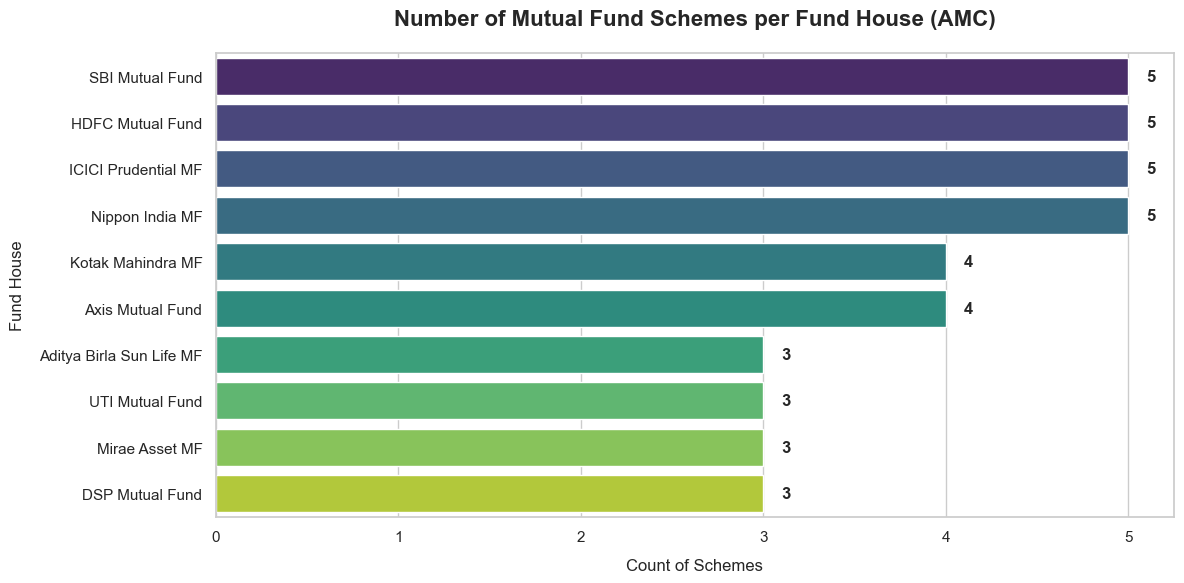

In [4]:
# Bar chart of number of funds per fund_house
fund_house_counts = df_fm["fund_house"].value_counts()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=fund_house_counts.values,
    y=fund_house_counts.index,
    hue=fund_house_counts.index,
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Number of Mutual Fund Schemes per Fund House (AMC)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Count of Schemes", fontsize=12, labelpad=10)
plt.ylabel("Fund House", fontsize=12, labelpad=10)

# Add count labels to the bars
for i, v in enumerate(fund_house_counts.values):
    ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.show()